License

- Content (explanatory text, figures): CC BY 4.0 — see /LICENSE-CONTENT
- Code cells and standalone code files: MIT License — see /LICENSE-CODE

Attribution example: Getman, R. (2026). CBE 3610 Python Notebooks and Course Materials. https://github.com/dr-rachel-bg-teaching/CBE3610


# Numerical Integration for Reactor Design

## Why Are We Learning This?
A key numerical method needed for reactor design is numerical integration. In this class we will use it for integrating Levenspiel plots and residence time distribution data. This example illustrates integration of a Levenspiel plot to estimate PFR volume given experimental rate vs. conversion data.


## Learning Objectives
- Construct a Levenspiel plot from reaction-rate data
- Calculate $\frac{1}{-r_A}$ from experimental or simulated data
- Apply the trapezoid rule for numerical integration
- Interpret the integrated value in the context of PFR design
- Connect numerical integration to reactor-sizing equations used in CBE 3610

In [ ]:
import numpy as np
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import cumulative_simpson
import matplotlib.pyplot as plt

## 1. Data Preparation

Let's do an example where you have experimentally measured rate vs conversion data:


| X | -rA (mol/L*min) |
|:--------:|:--------:|
|  0.0   |  0.12   |
|  0.1   |  0.0972   |  
|  0.2   |  0.0768   |
|  0.3   |  0.0588  |
|  0.4   |  0.0432   |
|  0.5   |  0.0300  |
|  0.6   |  0.0192   |
|  0.7   |  0.0108  |
|  0.8   |  0.0048  |
|  0.9   |  0.0012  |
|  0.95   | 0.0003   |

Let's load the data into arrays:


In [ ]:
X = np.array([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95])
nrA = np.array([0.12,0.0972,0.0768,0.0588,0.0432,0.03,0.0192,0.0108,0.0048,0.0012,0.0003])

## 2. Construct the Levenspiel Plot
The Levenspiel plot is a graph of $\frac{F_{A0}}{-r_A}$ versus conversion $X$. Let's plot the data for $F_{A0}$ = 6 mol/min.

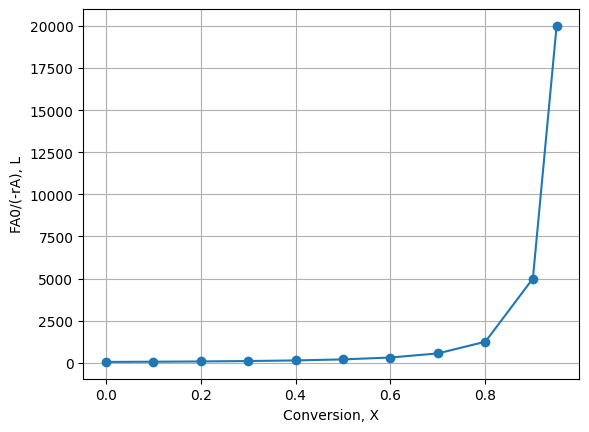

In [ ]:
lev = 1/nrA

plt.plot(X, 6*lev, 'o-')
plt.xlabel('Conversion, X')
plt.ylabel('FA0/(-rA), L')
plt.grid(True)
plt.show()

## 3. Use numeric integration

The PFR volume is equal to the area under the Levenspiel plot between 0 and X times the inlet molar flowrate of the PFR. There are multiple methods available to do numerical integration. Two popular ones are the trapezoid rule and Simpson's rule. Both of these are available in scipy. To compute the integral for each value in X in one line of code, use the "cumulative integral" versions of these methods.

Here are the PFR volumes needed to achieve the conversion values in X using the trapezoid rule:

In [ ]:
cumulative_trap = 6*cumulative_trapezoid(lev, X, initial=0)
print("Cumulative values:", cumulative_trap)

Cumulative values: [   0.            5.58641975   12.57908951   21.58738032   33.63386558
   50.57831003   76.20331003  119.60608781  209.88386558  522.38386558
 1147.38386558]


And here are the values using Simpson's rule:

In [ ]:
cumulative_simp = 6*cumulative_simpson(lev, x=X, initial=0)
print("Cumulative values:", cumulative_simp)

Cumulative values: [  0.           5.547518    12.50128601  21.40180802  33.34052448
  49.85672819  75.05348744 114.69469115 201.21089485 222.04422819
 810.58589485]


Note the difference:

In [ ]:
diff1 = cumulative_trap - cumulative_simp
print("Difference between the trapezoid rule and Simpson's rule:", diff1)

Difference between the trapezoid rule and Simpson's rule: [0.00000000e+00 3.89017490e-02 7.78034979e-02 1.85572300e-01
 2.93341102e-01 7.21581843e-01 1.14982258e+00 4.91139666e+00
 8.67297073e+00 3.00339637e+02 3.36797971e+02]


Both methods give about the same result until the curvature in FA0/(-rA) becomes steep. In this region, we can probably trust Simpson's rule more, since it is more accurate.

## Engineering insight:

Notice how the volume increases very rapidly after X = 0.9. Why does this happen?

As the conversion approaches 1, the reaction rate approaches 0. Hence, each additional increment of conversion requires significantly more reactor volume. This is one of the most important concepts hidden in the data.

## 4. Reactor Design Interpretation
For a Plug Flow Reactor:

$$F_{A0} \frac{dX}{dV} = -r_A$$

which can be rearranged to:

$$V = F_{A0} \int  \frac{dX}{-r_A} $$

Therefore, the integrated value computed above represents the quantity V/FA0 needed to achieve the desired conversion. The larger the area under the Levenspiel plot, the larger the reactor required.

# Interpolation

## Why are we learning this?

In the example above, we computed the PFR volume for the specific data points where tabulated experimental data exists. But what if we want to compute the volume for an intermediate conversion? In this case, we can use numerical interpolation.

## Lagrange Polynomials

One method for performing interpolation is to use Lagrange polynomials. Lagrange polynomials are expressed as follows:

$$
f_n(x) = \sum_{i=0}^n L_i(x) f(x_i)
$$

where $L_i(x)$ is the $i^\text{th}$ Lagrange basis polynomial defined as:

$$
L_i(x) = \prod_{j=0, j\neq i}^n \frac{x - x_j}{x_i - x_j}.
$$

The following code creates a function that constructs a Lagrange polynomial for a set of data and uses it to estimate a function value a given datapoint.

In [ ]:
def lagrange_polynomial(x_points, y_points, x):
  """
  Perform Langrange polynomial interpolation to determine the value at x, given a set of points x_points and y_points

  Parameters:
  x_points: array of x values
  y_points: array of y values
  x: array of x values to evaluate the polynomial at

  Returns:
  array of interpolated y values evaluated at x
  """

  #initialize input
  x = np.array(x)

  # initialize output
  fn = np.zeros(len(x))

  # create function for Li

  for i in range(len(x_points)):
    Li = np.ones(len(x))
    for j in range(len(x_points)):
      if i != j:
        Li *= (x - x_points[j]) / (x_points[i] - x_points[j])
    # times fi by Li and sum
    fn += y_points[i]*Li

  return fn

## Finding an intermediate value of FA0/(-rA):

Say for example we want to estimate the PFR volume needed to achieve 78% conversion. Then, x = 0.78:

In [ ]:
x = np.array([0.78])

lev_int = 6*lagrange_polynomial(X, lev, x)
print(lev_int)

[1095.30466687]


So, at X = 0.78, FA0/(-rA) = 1095.3 L. This makes sense, given the two adjacent values:

In [ ]:
print('At X = 0.7, FA0/(-rA) is ',6/.0108,' L.')
print('At X = 0.8, FA0/(-rA) is ',6/.0048,' L.')

At X = 0.7, FA0/(-rA) is  555.5555555555555  L.
At X = 0.8, FA0/(-rA) is  1250.0  L.


If we then wanted to integrate to this value, we could update the vectors:

In [ ]:
X_up = np.array([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.78,0.8,0.9,0.95])
nrA_up = np.array([0.12,0.0972,0.0768,0.0588,0.0432,0.03,0.0192,0.0108,6/1095.30466687,0.0048,0.0012,0.0003])
lev_up = 1/nrA_up

And then re-integrate:

In [ ]:
cumulative_simp_up = 6*cumulative_simpson(lev_up, x=X_up, initial=0)
print("Cumulative values:", cumulative_simp_up)

Cumulative values: [   0.            5.547518     12.50128601   21.40180802   33.34052448
   49.85672819   75.05348744  114.45968343  178.44784245  201.5701643
  472.72956244 1061.2712291 ]


Notice that this changes some of the values from the original Simpson integration:

In [ ]:
for i in range(len(X_up)):
  if X_up[i] < 0.78:
    print('X = ',X_up[i],' Volume using this dataset = ',cumulative_simp_up[i],' Difference from the original dataset: ',cumulative_simp_up[i]-cumulative_simp[i])
  elif X_up[i] > 0.78:
    print('X = ',X_up[i],' Volume using this dataset = ',cumulative_simp_up[i],' Difference from the original dataset: ',cumulative_simp_up[i]-cumulative_simp[i-1])

X =  0.0  Volume using this dataset =  0.0  Difference from the original dataset:  0.0
X =  0.1  Volume using this dataset =  5.547518004115227  Difference from the original dataset:  0.0
X =  0.2  Volume using this dataset =  12.501286008230453  Difference from the original dataset:  0.0
X =  0.3  Volume using this dataset =  21.40180802259175  Difference from the original dataset:  0.0
X =  0.4  Volume using this dataset =  33.3405244813975  Difference from the original dataset:  0.0
X =  0.5  Volume using this dataset =  49.8567281851012  Difference from the original dataset:  0.0
X =  0.6  Volume using this dataset =  75.05348744436046  Difference from the original dataset:  0.0
X =  0.7  Volume using this dataset =  114.45968342966138  Difference from the original dataset:  -0.23500771840276968
X =  0.8  Volume using this dataset =  201.57016430270775  Difference from the original dataset:  0.35926945093982
X =  0.9  Volume using this dataset =  472.72956243673553  Difference from

The values change because the integral at each point relies on the values of the surrounding points. We see the largest variation where the data has large curvature, consistent with the difficulty in fitting datasets with large curvature.

# Regression

## Why are we learning this?

Another strategy for numerical integration is to first fit a polynomial to the data and then integrate the polynomial. The integration can be performed either numerically or analytically.

For this approach to work well, the polynomial must provide a good representation of the data. In many cases, achieving a good fit requires a relatively high order polynomial. However, there is an important risk: higher order polynomial ▶ greater risk of overfitting ▶ oscillations and artificial noise ▶ errors in the integral.

Overfitting occurs when the polynomial begins fitting random variations in the data rather than the underlying trend. As a result, the fitted curve may exhibit unrealistic oscillations between data points, even if it passes through most or all of the points. Because integration depends on the area under the curve, these oscillaitons can introduce significant errors into the calculated integral.

A polynomial can be a good choice when:
- The data is smooth
- The fitted curve closely follows the expected physical behavior
- The fit does not exhibit significant oscillations
- Residuals are small and randomly distributed

When these conditions are met, integrated the fitted polynomial can produce results that are comparable to or better than traditional numerical integration methods.

## The polyfit function

The following function uses the polyfit function in numpy to fit a polynomial to x,y data:

In [ ]:
def fit_polynomial(x_points, y_points, order):
    """
    Fit an n-th order polynomial to x,y data.

    Parameters:
    x_points: array of x values
    y_points: array of y values
    order: integer: the desired polynomial order

    Returns:
    coeffs: array of polynomial coefficients
    y_fit: array of fitted y values
    r2: Coefficient of determination.
    poly: The fitted polynomial.
    """

    # Fit polynomial
    coeffs = np.polyfit(x_points, y_points, order)

    # Create polynomial
    poly = np.poly1d(coeffs)

    # Predicted values
    y_fit = poly(x_points)

    # Compute R^2
    ss_res = np.sum((y_points - y_fit)**2)
    ss_tot = np.sum((y_points - np.mean(y_points))**2)

    r2 = 1 - ss_res / ss_tot

    return coeffs, y_fit, r2, poly

## Fitting the data

Here, I tried polynomials of order 3 up to order 9. It took a 4th order polynomial to get R^2 ~ 0.9. It took a 9th order polynomial to reduce the oscillations and noise. (Try it!) However, the oscillations may still be too large, given the large range in the y-axis.

In [ ]:
coeffs3, y_fit3, r23, poly3 = fit_polynomial(X, lev, order=3)
coeffs6, y_fit6, r26, poly6 = fit_polynomial(X, lev, order=6)
coeffs9, y_fit9, r29, poly9 = fit_polynomial(X, lev, order=9)

print("order = 3, R^2 =", r23)
print("order = 6, R^2 =", r26)
print("order = 9, R^2 =", r29)

order = 3, R^2 = 0.8005097393410303
order = 6, R^2 = 0.983541088531856
order = 9, R^2 = 0.9999707177724347


Now let's plot the data along with the original data so that we can compare:

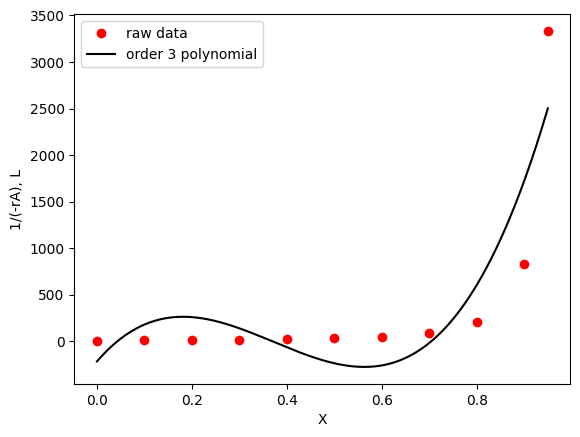

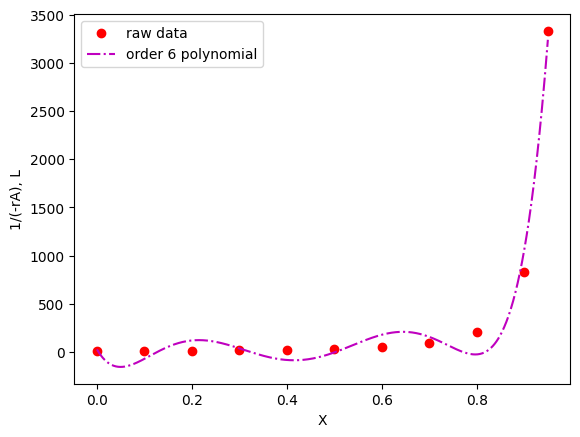

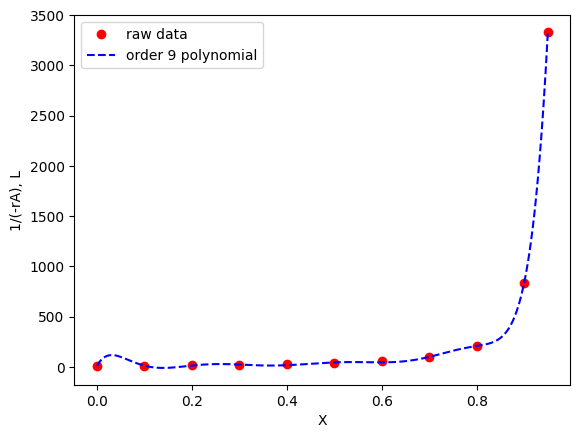

In [ ]:
x_list = np.linspace(min(X), max(X), 1001)
y_list3 = np.polyval(coeffs3, x_list)
y_list6 = np.polyval(coeffs6, x_list)
y_list9 = np.polyval(coeffs9, x_list)

plt.plot(X, lev, 'ro', label='raw data')
plt.plot(x_list, y_list3, 'k-', label='order 3 polynomial')
plt.legend()
plt.xlabel('X')
plt.ylabel('1/(-rA), L')
plt.show()

plt.plot(X, lev, 'ro', label='raw data')
plt.plot(x_list, y_list6, 'm-.', label='order 6 polynomial')
plt.legend()
plt.xlabel('X')
plt.ylabel('1/(-rA), L')
plt.show()

plt.plot(X, lev, 'ro', label='raw data')
plt.plot(x_list, y_list9, 'b--', label='order 9 polynomial')
plt.legend()
plt.xlabel('X')
plt.ylabel('1/(-rA), L')
plt.show()

The order 9 polynomial minimizes oscillations and noise.

## Another check:

The R^2 value for our fit is good, but that doesn't always mean a good fit. The graph above gives credence to the fit, but the y-axis values are large (if we zoomed in on any portion, we might see larger errors than are possible to see on this graph due to the way it's rendered). Hence, it's important to check the residuals:

In [ ]:
residuals = lev - y_fit
print("Residuals:", residuals)

Residuals: [ 0.03721377 -0.37432669  1.69694764 -4.56870519  8.0990683  -9.89886126
  8.48473822 -5.09084293  2.12118455 -0.70706152  0.2006451 ]


These residuals are small, which is a good sign.

# Integrate the polynomial

Our analysis of the polynomial fit suggests that it could be a good fit to the data and also a good strategy for integrating the data. We can integrate functions using Gaussian Quadrature:

In [ ]:
from scipy import integrate

def integrand(x):
  order = len(coeffs)-1
  y = 0
  for i in range(len(coeffs)):
    y += coeffs[i] * x**(order-i)
  return y

for i in range(len(X)):
  integ_y, err = integrate.quad(integrand, 0, X[i])
  print('Volume using this method = ',6*integ_y," Difference from Simpson's rule: ", 6*integ_y-cumulative_simp[i])

Volume using this method =  0.0  Difference from Simpson's rule:  0.0
Volume using this method =  43.591251162504285  Difference from Simpson's rule:  38.04373315838906
Volume using this method =  41.52650417388688  Difference from Simpson's rule:  29.025218165656426
Volume using this method =  55.235494566891  Difference from Simpson's rule:  33.83368654429925
Volume using this method =  63.975861862937904  Difference from Simpson's rule:  30.635337381540403
Volume using this method =  81.55917910754152  Difference from Simpson's rule:  31.702450922440327
Volume using this method =  108.68147391100788  Difference from Simpson's rule:  33.62798646664743
Volume using this method =  145.03322831673853  Difference from Simpson's rule:  30.338537168674378
Volume using this method =  238.90280191203084  Difference from Simpson's rule:  37.691907060262906
Volume using this method =  454.1534117714807  Difference from Simpson's rule:  232.1091835863799
Volume using this method =  997.68845569

# So what method should I use?

Like with many engineering problems, there is not a straightforward guide. Here is some guidance based on what we did in this exercise:

- Simpson's rule is very commonly used in reactor design. It is more accurate than the trapezoid rule since it uses parabolas rather than lines to construct integrals. And it can be done in two lines of code. Also, python automatically takes care of non-equally spaced datapoints.
- The problem with Simpson's rule is when we want a reactor volume at a conversion where we don't have raw data. In that case, we can use either interpolation or regression to obtain the new datapoint, and then we can integrate. Here we integrated using Simpson's rule and analytical integration.

## Everything we've done here are models

We have used a variety of strategies for estimating PFR volume. All strategies have their pros and their cons. Typically in modeling, the "best" strategy is: take the simplest model that accurately represents the data. One way to think of "simplest" is: the model with the fewest assumptions. Simpson's rule makes the fewest assumptions because it uses the data directly. As an added bonus, it can be carried out in just two lines of code.